# SegRap2023 to NPZ Conversion and Visualization

This notebook converts SegRap2023 dataset `.nii.gz` files into a unified `.npz` format for testing. It supports processing both non-contrast (ncCT) and contrast-enhanced (ceCT) scans.

In [1]:
import sys
from pathlib import Path
import os
import numpy as np

parent = Path().resolve().parent.parent 
if str(parent) not in sys.path:
    sys.path.append(str(parent))

from data.test_data.segrap_to_npz import SegRapProcessor
from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator import DataGenerator
from utils.visualization import visualize_img_with_mask, plot_vol_slices, plot_one_dp

## 1. Process SegRap2023 Dataset

We use the `SegRapProcessor` to resample images and combine 45 OARs and 2 GTVs masks to 1.0mm isotropic resolution (with cropping to anatomy). Overlapping organs are handled seamlessly by applying masks ordered by descending volume.

In [ ]:
data_dir = "SegRap2023"
modality = "ncct" # Can be changed to "cect" for contrast enhanced
output_name = "SegRap2023"

if os.path.isdir(data_dir):
    proc = SegRapProcessor(data_dir, modality=modality)
    proc.process_dataset(output_name)
else:
    print(f"Data directory {data_dir} not found. Please ensure it exists.")


[1/40] Processing segrap_0000 (ncCT) ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('3.00', '0.53', '0.53') mm → 1.0 mm isotropic ...
  -> Resampled shape: (381, 358, 545)

[2/40] Processing segrap_0003 (ncCT) ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('3.00', '0.51', '0.51') mm → 1.0 mm isotropic ...
  -> Resampled shape: (360, 418, 523)

[3/40] Processing segrap_0006 (ncCT) ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('3.00', '0.62', '0.62') mm → 1.0 mm isotropic ...
  -> Resampled shape: (363, 407, 574)

[4/40] Processing segrap_0009 (ncCT) ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('3.00', '0.48', '0.48') mm → 1.0 mm isotropic ...
  -> Resampled shape: (399, 383, 490)

[5/40] Processing segrap_0012 (ncCT) ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('3.00', '0.49', '0.49') mm → 1.0 mm isotropic ...
  -> Resampled shape: (390, 396, 502)

[6/40] Processing segrap

## 2. Load and Visualize

Now we load the generated `.npz` file and visualize a few sample scans.

In [7]:
npz_path = Path(f"{output_name}.npz").resolve()

if os.path.exists(npz_path):
    dg = DataGenerator(DataLoader_npz([npz_path], val_size=0.0))
    all_ids = dg.dataloader.train_ids
    print(f"Loaded IDs: {all_ids[:5]} ... (total {len(all_ids)})")
    
    sample_id = all_ids[0]
    img = dg.dataloader.dataset[sample_id]['image']
    mask = dg.dataloader.dataset[sample_id]['segmentations']
    
    print(f"Sample: {sample_id}")
    print(f"Image shape: {img.shape}")
    print(f"Mask shape: {mask[0].shape}")
else:
    print(f"Skipping loading, file {npz_path} not found.")


Loading NPZ dataset(s)…
Loaded 40 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\test_data\SegRap2023.npz

Final dataset size: 40 patients.

Loaded IDs: ['SegRap2023_segrap_0039', 'SegRap2023_segrap_0000', 'SegRap2023_segrap_0093', 'SegRap2023_segrap_0021', 'SegRap2023_segrap_0027'] ... (total 40)
Sample: SegRap2023_segrap_0039
Image shape: (375, 371, 574)
Mask shape: (375, 371, 574)


### Interactive Visualization

Note: This interactive view will not be saved when you restart the notebook.

In [8]:
if os.path.exists(npz_path):
    visualize_img_with_mask(img, mask[0])

interactive(children=(IntSlider(value=187, description='Slice:', max=374), Output()), _dom_classes=('widget-in…

### Static Persistent Visualization

This grid view is saved in the notebook, so you can see it later even without a running kernel.

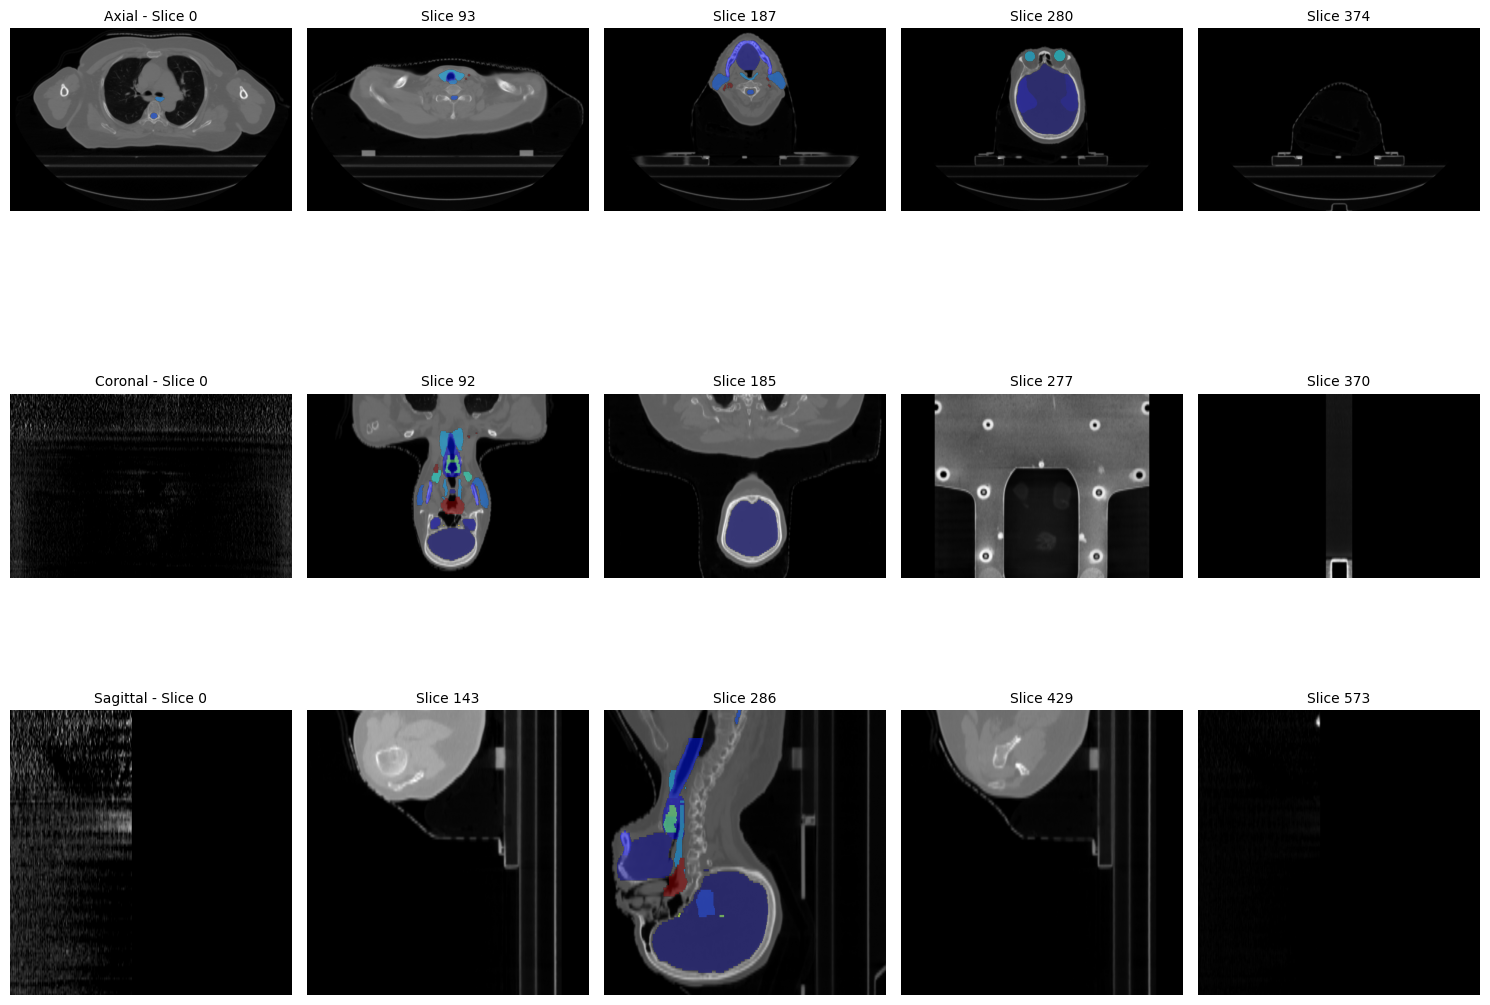

In [14]:
plot_vol_slices(img, mask[0])